In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath("C://Users//pc//Desktop//Week 1//news_sentiment_analysis//src//"))

In [3]:
from src.data_loader import load_data
#from src.stock_analysis import ensure_correct_types,handle_missing_values,calculate_moving_averages,calculate_rsi
#from src.stock_analysis import calculate_macd,get_macd_signals
from src.visualization import plot_macd

print('Functions imported successfully!')

Functions imported successfully!


In [6]:
df = load_data('C:/Users/pc/Desktop/Week 1/news_sentiment_analysis/data/AAPL.csv')
df.head()

,date,close,high,low,open,volume
0,2009-01-02 00:00:00+00:00,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05 00:00:00+00:00,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06 00:00:00+00:00,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07 00:00:00+00:00,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08 00:00:00+00:00,2.780169,2.793666,2.700393,2.712090,673500800


## Data preparation

In [7]:
# Example usage
df = ensure_correct_types(df)
print(df.dtypes)

date      datetime64[us, UTC]
close                 float64
high                  float64
low                   float64
open                  float64
volume                  int64
dtype: object


In [8]:
# Checking and handling for missing values 
df = handle_missing_values(df, strategy="mean")

Missing Values Per Column:
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64

Remaining Missing Values:
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


## Computing Technical Indicators with TA-Lib

In [12]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume'], dtype='str')

In [13]:
df_MA = calculate_moving_averages(df,column="close",windows=[5, 10, 20, 50])
print(df_MA.head())

                       date     close      high       low      open  \
0 2009-01-02 00:00:00+00:00  2.721686  2.730385  2.554037  2.575630   
1 2009-01-05 00:00:00+00:00  2.836553  2.884539  2.780469  2.794266   
2 2009-01-06 00:00:00+00:00  2.789767  2.914229  2.770872  2.877641   
3 2009-01-07 00:00:00+00:00  2.729484  2.774170  2.706990  2.753477   
4 2009-01-08 00:00:00+00:00  2.780169  2.793666  2.700393  2.712090   

       volume     SMA_5     EMA_5  SMA_10    EMA_10  SMA_20    EMA_20  SMA_50  \
0   746015200       NaN  2.721686     NaN  2.721686     NaN  2.721686     NaN   
1  1181608400       NaN  2.759975     NaN  2.742571     NaN  2.732626     NaN   
2  1289310400       NaN  2.769906     NaN  2.751152     NaN  2.738068     NaN   
3   753048800       NaN  2.756432     NaN  2.747212     NaN  2.737250     NaN   
4   673500800  2.771532  2.764344     NaN  2.753205     NaN  2.741338     NaN   

     EMA_50  
0  2.721686  
1  2.726191  
2  2.728684  
3  2.728715  
4  2.730733  


In [26]:
df_rsi= calculate_rsi(df, column="close")
print(df_rsi[["RSI", "RSI_Signal"]].tail())

NameError: name 'np' is not defined

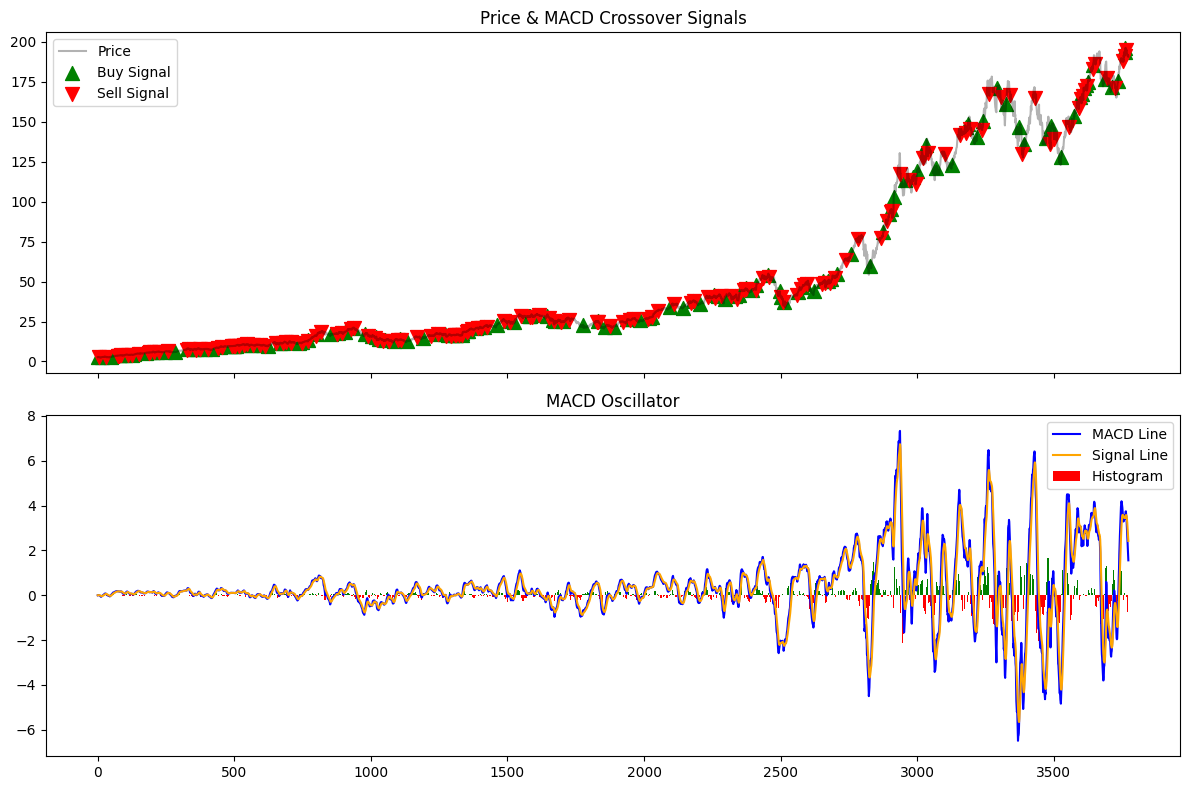

In [36]:

macd_results = calculate_macd(df['close'])
signal_results = get_macd_signals(macd_results)
plot_macd(df['close'], macd_results, signal_results)

## Apply PyNance 

In [37]:
%pip install pynance

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\pc\Desktop\Week 1\news_sentiment_analysis\venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "c:\Users\pc\Desktop\Week 1\news_sentiment_analysis\venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 248, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pc\Desktop\Week 1\news_sentiment_analysis\venv\Lib\site-packages\pip\_internal\commands\install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pc\Desktop\Week 1\news_sentiment_analysis\venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 356, in make_resolver
    import pip._internal.resolution.resolvelib.resolver
  File "c:\Users\pc\Desktop\Week 1\news_sentiment_analysis\venv\Lib\site-packages\pip\_internal\resolution\resolvelib\res

## Visualizing the Data

In [ ]:
plot_close_with_moving_averages( df,
     price_column="close",
    sma_windows=[5, 20, 50],
    ema_windows=[10, 30]
)

In [ ]:
plot_rsi_and_macd(df)

In [ ]:
plot_price_with_indicators(
    df,
    price_column="close",
    sma_windows=[20, 50],
    ema_windows=[10, 30]
)